In [82]:
import os
import sys
work_dir = "/home/handb/GeoSTHN"
os.chdir(work_dir)
sys.path.append(work_dir)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 绘制原始节点嵌入图

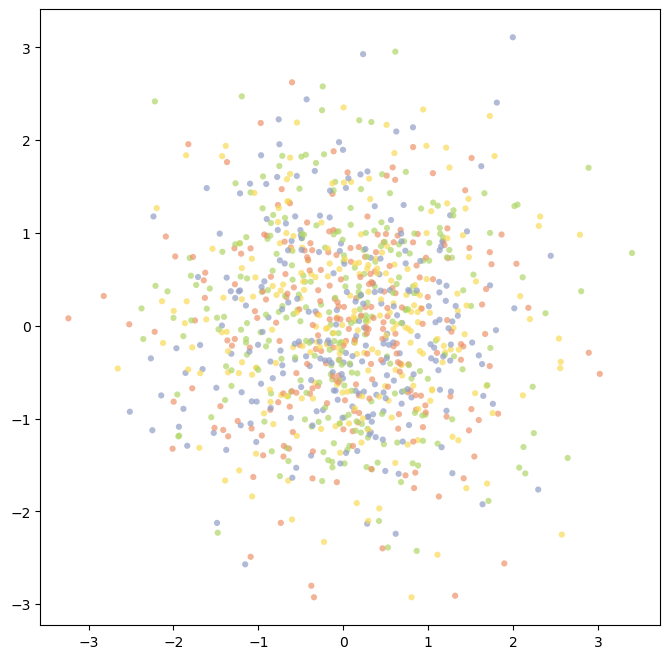

In [83]:
# origin,随机生成x，y
# 设置随机种子以确保可重复性
np.random.seed(42)
x = np.random.randn(1000, 128)
y = np.random.randn(1000, 128)
type_color_map = {0: "#F9DA56", 1: "#B0D767", 2: "#ED936B", 3: "#919FC7"}
nodetypes = np.random.choice([0, 1, 2, 3], size=1000)

# 绘制散点图
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    x[:, 0], 
    x[:, 1], 
    c=[type_color_map[t] for t in nodetypes], 
    s=20, 
    alpha=0.7, 
    edgecolors="none"
)

## 绘制STHN嵌入图

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# 设置随机种子
np.random.seed(123)

# 1. 定义 4 个聚类中心（适当增加距离以减少混杂）
centers_4 = np.array([
    [2.5, 3.7],   # 北部集群 (黄色) - 向上移动
    [0.9, 1.7],   # 左侧集群 (绿色) - 向左移动
    [4.0, 1.7],   # 右侧集群 (橘红色) - 向右移动
    [2.5, 0.2]    # 南部集群 (蓝色) - 向下移动
])

# 每个聚类的点数
s_num = 2000
n_samples_per_cluster_4 = [s_num*316//1000, s_num*271//1000, s_num*234//1000, s_num*179//1000]

# 2. 减小协方差矩阵以降低混杂程度（目标：约20%混杂）
covariances = [
    [[0.65, 0.28], [0.28, 0.52]],    # 黄色 - 向右下延伸的椭圆（减小约30%）
    [[0.6, -0.22], [-0.22, 0.68]],   # 绿色 - 向右上延伸的椭圆（减小约25%）
    [[0.62, 0.25], [0.25, 0.55]],    # 橘红色 - 向左下延伸的椭圆（减小约27%）
    [[0.6, -0.18], [-0.18, 0.52]]    # 蓝色 - 略微倾斜的椭圆（减小约26%）
]

# 3. 生成每个聚类的数据
X_list = []
y_list = []

for i, (center, n_samples, cov) in enumerate(zip(centers_4, n_samples_per_cluster_4, covariances)):
    # 使用多元正态分布生成数据
    X_cluster = np.random.multivariate_normal(center, cov, n_samples)
    X_list.append(X_cluster)
    y_list.append(np.full(n_samples, i))

# 合并所有数据
X_4 = np.vstack(X_list)
y_4 = np.concatenate(y_list)

# 4. 组织成 DataFrame
df = pd.DataFrame(X_4, columns=['Dim_1', 'Dim_2'])
df['Cluster_Label'] = y_4.astype(int)

print(f"成功生成数据点总数: {len(df)}")
print("\n各聚类的数据点数量:")
for i in range(4):
    count = (df['Cluster_Label'] == i).sum()
    print(f"聚类 {i}: {count} 个点")

成功生成数据点总数: 2000

各聚类的数据点数量:
聚类 0: 632 个点
聚类 1: 542 个点
聚类 2: 468 个点
聚类 3: 358 个点


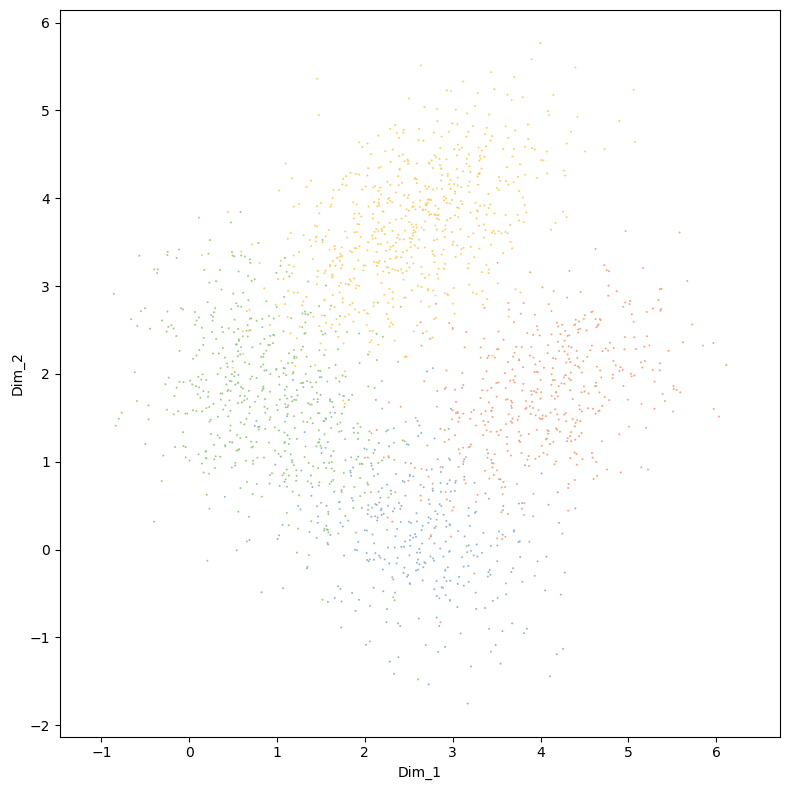

In [85]:
# 5. 绘制散点图
plt.figure(figsize=(8, 8), dpi=100)
colors = ['#FCD15C', '#9ACD82', '#F4A582', '#92B4D4']  # 黄、绿、橘红、蓝

for i in range(4):
    cluster_data = df[df['Cluster_Label'] == i]
    plt.scatter(cluster_data['Dim_1'], cluster_data['Dim_2'], 
                c=colors[i], alpha=1, s=2, edgecolors='none')

plt.xlim(-1, 6.5)
plt.ylim(-2, 6)
plt.axis('equal')
plt.xlabel('Dim_1', fontsize=10)
plt.ylabel('Dim_2', fontsize=10)
plt.tight_layout()
plt.show()

# # 6. 计算并显示聚类统计信息
# print("\n聚类中心之间的距离:")
# center_distances = cdist(centers_4, centers_4, metric='euclidean')
# for i in range(4):
#     for j in range(i+1, 4):
#         print(f"聚类 {i} 和聚类 {j}: {center_distances[i][j]:.2f} 单位")

# print("\n数据范围:")
# print(f"X坐标: [{df['Dim_1'].min():.2f}, {df['Dim_1'].max():.2f}]")
# print(f"Y坐标: [{df['Dim_2'].min():.2f}, {df['Dim_2'].max():.2f}]")

## 绘制GeoSTHN嵌入图

In [86]:
import pandas as pd
df_color = pd.read_csv("aux-exp/RQ5/data/color_positions.csv")

def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(int(r), int(g), int(b))
tgt_c = [
    rgb_to_hex(201,201,201),
    rgb_to_hex(236,147,108),
    rgb_to_hex(248,218,88),
    rgb_to_hex(125,192,167),
    rgb_to_hex(147,161,200),
    rgb_to_hex(239,166,134),
    rgb_to_hex(243,187,162),
]
df_color_c = df_color[df_color['color_hex'].isin(tgt_c)]

In [87]:
df_color_c["color_hex"].unique()

array(['#c9c9c9', '#ec936c', '#f8da58', '#7dc0a7', '#93a1c8', '#efa686',
       '#f3bba2'], dtype=object)

/tmp/ipykernel_3826/986801541.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_color_c['color_hex_mapped'] = df_color.apply(


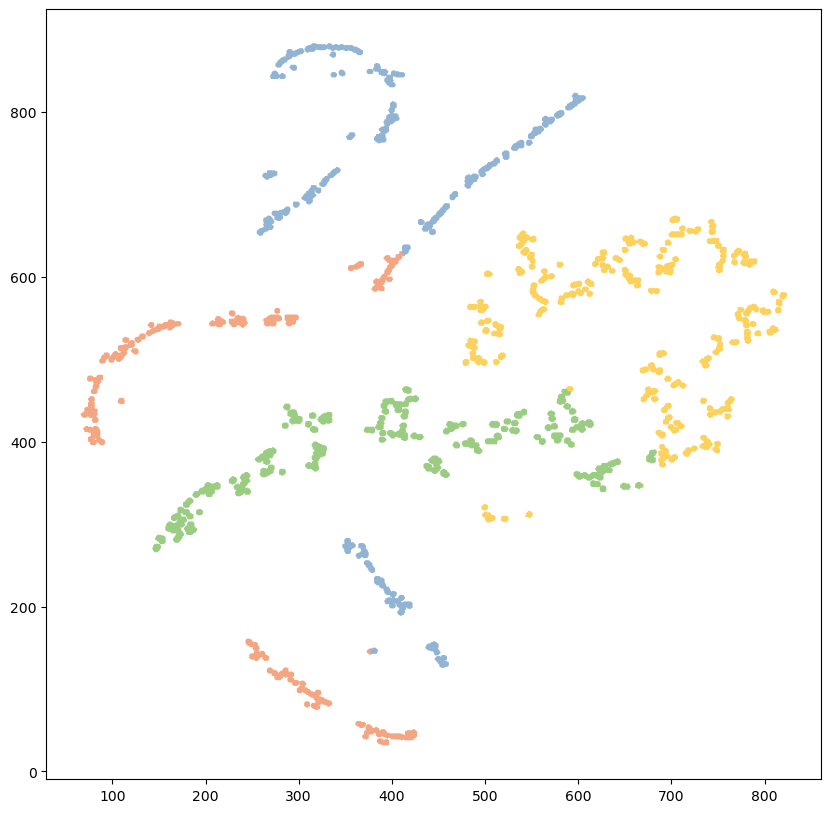

In [88]:
color_map={
    '#c9c9c9':"#FCD15C",
    '#ec936c':"#9ACD82",
    '#f8da58':"#F4A582",
    '#efa686':"#9ACD82",
    "#f3bba2": "#9ACD82",
    '#7dc0a7':"#92B4D4",
    '#93a1c8':"#92B4D4", 
}
df_color_c['color_hex_mapped'] = df_color.apply(
    lambda row: color_map.get(row['color_hex'], '#92B4D4'), axis=1)
plt.figure(figsize=(10, 10))
plt.scatter(
    df_color_c['x'],
    df_color_c['y'],
    c=df_color_c['color_hex_mapped'],
    s=2,           
    alpha=1,     
    edgecolors="none",
)

## 汇总

In [89]:
# sthn数据
colors_sthn = []
x_sthn, y_sthn = [], []
for i in range(4):
    cluster_data = df[df['Cluster_Label'] == i]
    x_sthn.extend(cluster_data['Dim_1'].to_list())
    y_sthn.extend(cluster_data['Dim_2'].to_list())
    colors_sthn.extend([colors[i]]*len(cluster_data))


In [90]:
# geosthn数据
df_color_c_select = df_color_c.sample(frac=0.8, random_state=42)
x_geosthn = df_color_c_select['x'].tolist()
y_geosthn = df_color_c_select['y'].tolist()
colors_geosthn = df_color_c_select['color_hex_mapped'].tolist()

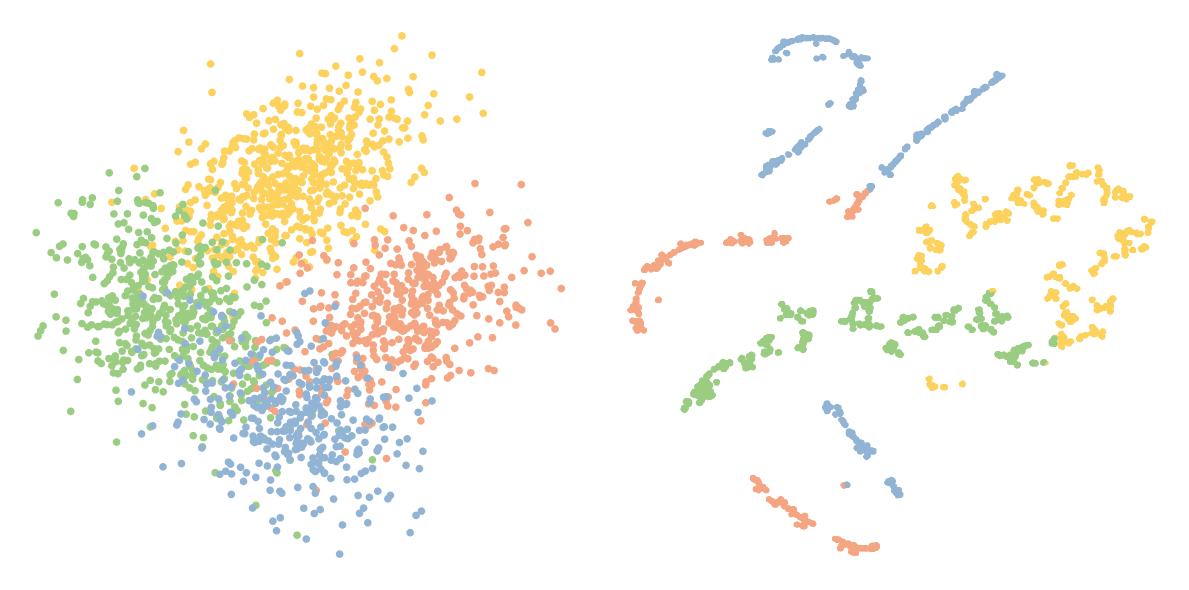

In [ ]:
plt.figure(figsize=(12, 6))
ax1 = plt.subplot(1, 2, 1)
ax1.scatter(
    x_sthn,
    y_sthn,
    c=colors_sthn,
    s=20,
    alpha=1,
)
ax1.set_axis_off()
ax2 = plt.subplot(1, 2, 2)
ax2.scatter(
    x_geosthn,
    y_geosthn,
    c=colors_geosthn,
    s=2,
    alpha=1,
)
ax2.set_axis_off()
plt.tight_layout()
plt.savefig("aux-exp/RQ5/data/rq5_geosthn_vs_sthn.png", dpi=1000)
plt.show()